# **TP2 - Etapa 1:** Buscador de Imágenes por Similitud

Notebook de trabajo de la Etapa 1: análisis del dataset, preprocesamiento, eleccion de modelo pre-entrenado, generación de embeddings, almacenamiento y evaluación por imágen de prueba. En éste se busca implementar las funciones *extract_embedding(image)*, *search_similar_images(embedding, top_k)*, *predict_breed_from_neighbors(results)*

### **Equipo**
- Alumno 1 : Balverdi, Valentina
- Alumno 2 : Prieto, Tobías

## Librerías

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import psycopg2
from pgvector.psycopg2 import register_vector
from sklearn.metrics import ndcg_score
import numpy as np
import os
import json
import uuid
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


## **1.1 Análisis del dataset y Preprocesamiento**

Se utiliza el **70 Dog Breeds Image Dataset** de Kaggle. Éste cuenta con 9346 imágenes de 70 razas de perros distribuidas en 3 conjuntos de datos (train, test y valid). A continuacion de desarrolla un análisis exploratorio.

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

### Distribución de clases 

In [15]:
import pandas as pd

splits = ['train', 'valid', 'test']
conteos = {}

for split in splits:
    split_path = Path(f'data/dataset/{split}')
    conteos[split] = {
        carpeta.name: len(list(carpeta.iterdir()))
        for carpeta in split_path.iterdir() if carpeta.is_dir()
    }

df_conteos = pd.DataFrame(conteos).fillna(0).astype(int)
df_conteos['total'] = df_conteos.sum(axis=1)
df_conteos = df_conteos.sort_values('total', ascending=False)

print(df_conteos.sum())  # totales por split
df_conteos.head(10)

train    7946
valid     700
test      700
total    9346
dtype: int64


,train,valid,test,total
Shih-Tzu,198,10,10,218
Lhasa,187,10,10,207
Labrador,161,10,10,181
Basset,159,10,10,179
Scotch Terrier,150,10,10,170
Pomeranian,149,10,10,169
Pug,148,10,10,168
Bloodhound,147,10,10,167
Boxer,134,10,10,154
Bermaise,131,10,10,151


In [18]:
df_conteos.describe()

,train,valid,test,total
count,71.000000,71.000000,71.000000,71.000000
mean,111.915493,9.859155,9.859155,131.633803
std,27.965155,1.186782,1.186782,28.694071
min,0.000000,0.000000,0.000000,10.000000
25%,98.500000,10.000000,10.000000,118.500000
50%,111.000000,10.000000,10.000000,131.000000
75%,125.000000,10.000000,10.000000,145.000000
max,198.000000,10.000000,10.000000,218.000000


In [19]:
clase_max = df_conteos['train'].idxmax()
clase_min = df_conteos['train'].idxmin()
ratio = df_conteos['train'].max() / df_conteos['train'].min()

print(f"Raza con más imágenes (train): {clase_max} ({df_conteos['train'].max()})")
print(f"Raza con menos imágenes (train): {clase_min} ({df_conteos['train'].min()})")
print(f"Ratio de desbalance (max/min): {ratio:.2f}")
print(f"Promedio de imágenes por raza: {df_conteos['train'].mean():.1f}")
print(f"Desvío estándar: {df_conteos['train'].std():.1f}")

Raza con más imágenes (train): Shih-Tzu (198)
Raza con menos imágenes (train): American  Spaniel (0)
Ratio de desbalance (max/min): inf
Promedio de imágenes por raza: 111.9
Desvío estándar: 28.0


C:\Users\valen\AppData\Local\Temp\ipykernel_20160\494513179.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = df_conteos['train'].max() / df_conteos['train'].min()


### EL perro que no marcheaba donde se corrige???

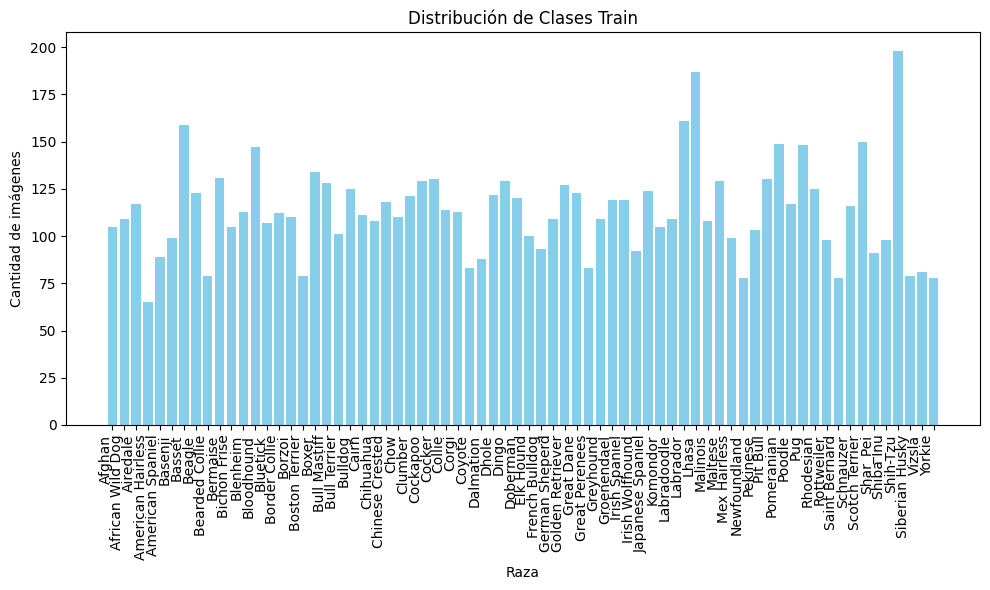

In [16]:
conteo = {}

# Recolectar datos
for carpeta in base_path.iterdir():
    if carpeta.is_dir():  
        conteo[carpeta.name] = len(list(carpeta.iterdir()))

# Graficar
plt.figure(figsize=(10, 6))
plt.bar(conteo.keys(), conteo.values(), color='skyblue')

plt.title('Distribución de Clases Train')
plt.xlabel('Raza')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### **Corrección del desbalance**
COMPLETAR:  Como observamos, hay un desbalanceo de clases. PAra disuadirlo, se creo un script donde se crean......

HACER un solo grafico para ver la distibucion de clases de los distintos dataset, total ya se vio en la muestra que solo hay 10 img en val y test para cada una y va quedar bien igual .

In [ ]:
#  !python scripts/balance_train_dataset.py

In [ ]:
conteo = {}

val_path = Path('data/dataset/valid')
# Recolectar datos
for carpeta in val_path.iterdir():
    if carpeta.is_dir():  
        conteo[carpeta.name] = len(list(carpeta.iterdir()))

# Graficar
plt.figure(figsize=(10, 6))
plt.bar(conteo.keys(), conteo.values(), color='skyblue')

plt.title('Distribución de Clases Validacion')
plt.xlabel('Raza')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 1.3 ...

## Instanciación del modelo y preprocesamiento

Se uso ConvNeXt_Tiny para implementar 
mecanismo de atencion igual que las redes treansformers, mejora a una CNN normal. se uso un nano para que la velocidad de inferencia sea mejor. 

evaluando las metricas de NDC... se observo que todas tienen un valor superior a... lo que indica que ....


In [4]:
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)

model.classifier[2] = torch.nn.Identity()   # remplaza la ultima capa por la identidad, devuelve vector de 768
model.eval()
preprocess = weights.transforms()

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\valen/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:04<00:00, 25.6MB/s] 


## Función para obtener embeddings

In [5]:
def obtener_embedding (image:np.ndarray) -> list[float]:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(image_rgb)
        image_tensor = preprocess(image_pil).unsqueeze(0)

        with torch.inference_mode():
            embedding = model(image_tensor).squeeze(0)

        return embedding.cpu().tolist()

## Conexión con la base de datos

In [7]:
conn = psycopg2.connect(
    dbname="dogs", 
    user="dogs_user", 
    password="dogs_pass", 
    host="localhost", 
    port="5432"
)
cur = conn.cursor()
cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
register_vector(conn)

cur.execute("""
    CREATE TABLE IF NOT EXISTS embeddings (
        id_imagen VARCHAR PRIMARY KEY,
        embedding vector(768),
        path VARCHAR NOT NULL,
        breed VARCHAR NOT NULL,
        metadata JSONB
    );
""")
conn.commit()

## Agregar los registros de train a la base

In [8]:
def indexar_dataset(ruta_dataset):
    for raza in os.listdir(ruta_dataset):
        raza_path = os.path.join(ruta_dataset, raza)
            
        for img_name in os.listdir(raza_path):
            img_path = os.path.join(raza_path, img_name)
            
            image = cv2.imread(img_path)
            if image is None: 
                continue
                
            emb = obtener_embedding(image)
            img_id = str(uuid.uuid4())  
            
            cur.execute("""
                INSERT INTO embeddings (id_imagen, embedding, path, breed, metadata)
                VALUES (%s, %s, %s, %s, %s)
            """, (img_id, emb, img_path, raza, json.dumps({"source": "train"})))
    conn.commit()

indexar_dataset("data/dataset_balanced/train")

## Busqueda por similitud

In [9]:
def buscar_similar(query_embedding, top_k=10, metric='cosine'):
    emb_str = str(query_embedding)
    
    if metric == 'cosine':
        query = """
            SELECT path, breed, 1 - (embedding <=> %s::vector) AS score
            FROM embeddings ORDER BY embedding <=> %s::vector LIMIT %s;
        """
    else:
        query = """
            SELECT path, breed, (embedding <-> %s::vector) AS score
            FROM embeddings ORDER BY embedding <-> %s::vector LIMIT %s;
        """
        
    cur.execute(query, (emb_str, emb_str, top_k))
    return cur.fetchall()

## Función para graficar las imágenes similares

In [10]:
def plot_similares(image: np.ndarray, top_k: int = 10, metric: str = 'cosine'):
    emb = obtener_embedding(image)
    
    resultados = buscar_similar(emb, top_k, metric)
    
    fig = plt.figure(figsize=(15, 5))
    
    ax_query = fig.add_subplot(2, 6, 1)
    ax_query.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax_query.set_title("Consulta", fontweight='bold')
    ax_query.axis("off")
    
    for i, (path, breed, score) in enumerate(resultados):
        img_res = cv2.imread(path)
        pos = i + 2 if i < 5 else i + 3
        
        ax_res = fig.add_subplot(2, 6, pos)
        if img_res is not None:
            ax_res.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
            
        ax_res.set_title(f"{breed}\nScore: {score:.3f}", fontsize=9)
        ax_res.axis("off")
        
    plt.tight_layout()
    plt.show()

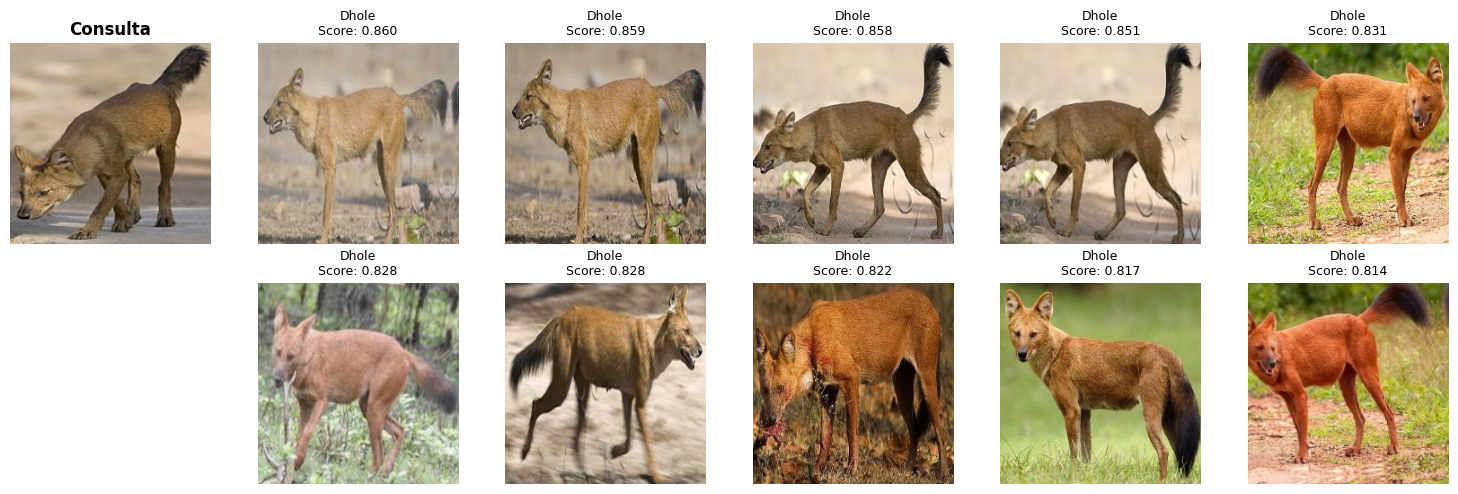

In [11]:
imagen_consulta = cv2.imread("data/dataset/test/Dhole/01.jpg")

if imagen_consulta is not None:
    plot_similares(imagen_consulta)
else:
    print("error")


## Buscar por vecinos cercanos

In [12]:
def predecir_raza_desde_vecinos(
    resultados: list[tuple[str, str, float]],
    similarity_threshold: float = 0.55,
    metric: str = "cosine",
) -> tuple[str, float]:
    """Predice la raza mediante voto ponderado por similitud.

    Cada resultado debe tener la forma (path, breed, score). Para L2,
    buscar_similar devuelve una distancia, por lo que se transforma a
    similitud con 1 / (1 + distancia) antes de realizar la votacion.
    """
    if not resultados:
        return "unknown", 0.0

    vecinos = []
    for path, breed, score in resultados:
        score = float(score)
        similitud = 1.0 / (1.0 + score) if metric.lower() == "l2" else score
        vecinos.append((path, breed, similitud))

    mejor_score = max(score for _, _, score in vecinos)
    if mejor_score < similarity_threshold:
        return "unknown", mejor_score

    votos = {}
    mejor_score_por_raza = {}
    for _, breed, score in vecinos:
        votos[breed] = votos.get(breed, 0.0) + score
        mejor_score_por_raza[breed] = max(
            mejor_score_por_raza.get(breed, float("-inf")),
            score,
        )

    raza_predicha = max(
        votos,
        key=lambda breed: (
            votos[breed],
            mejor_score_por_raza[breed],
            breed,
        ),
    )
    return raza_predicha, mejor_score_por_raza[raza_predicha]


def predecir_raza(
    image: np.ndarray,
    top_k: int = 10,
    metric: str = "cosine",
    similarity_threshold: float = 0.55,
):
    """Ejecuta el flujo embedding -> vecinos cercanos -> raza predicha."""
    embedding = obtener_embedding(image)
    resultados = buscar_similar(embedding, top_k=top_k, metric=metric)
    raza, score = predecir_raza_desde_vecinos(
        resultados,
        similarity_threshold=similarity_threshold,
        metric=metric,
    )
    return raza, score, resultados



if imagen_consulta is not None:
    raza_predicha, score_prediccion, vecinos = predecir_raza(imagen_consulta)
    print(f"Raza predicha: {raza_predicha}")
    print(f"Score: {score_prediccion:.4f}")
    print(f"Vecinos recuperados: {len(vecinos)}")


Raza predicha: Dhole
Score: 0.8601
Vecinos recuperados: 10


## Calculo de NDCG@10 por clase

In [23]:
def calcular_ndcg_por_raza(k: int = 10, metric: str = 'cosine'):
    cur.execute("SELECT id_imagen, embedding, breed FROM embeddings")
    dataset = cur.fetchall()
    
    operador = '<=>' if metric == 'cosine' else '<->'
    ndcg_por_raza = {}
    conteos_por_raza = {}
    
    for id_img, emb, raza_true in dataset:
        # Aseguramos que conserve las comas al pasarlo a texto
        emb_str = str(emb.tolist() if hasattr(emb, 'tolist') else list(emb))
        
        query = f"""
            SELECT breed FROM embeddings
            WHERE id_imagen != %s
            ORDER BY embedding {operador} %s
            LIMIT %s
        """
        cur.execute(query, (id_img, emb_str, k))
        resultados = cur.fetchall()
        
        relevancias = [1 if res[0] == raza_true else 0 for res in resultados]
        dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(relevancias))
        idcg = sum(1 / np.log2(i + 2) for i in range(k))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        
        ndcg_por_raza[raza_true] = ndcg_por_raza.get(raza_true, 0.0) + ndcg
        conteos_por_raza[raza_true] = conteos_por_raza.get(raza_true, 0) + 1
        
    for raza in ndcg_por_raza:
        ndcg_por_raza[raza] /= conteos_por_raza[raza]
        
    return ndcg_por_raza

# conn.rollback()
resultados_ndcg = calcular_ndcg_por_raza(k=10, metric='cosine')
for raza, score in resultados_ndcg.items():
    print(f"Raza: {raza} | NDCG@10: {score:.4f}")

Raza: Afghan | NDCG@10: 0.9888
Raza: African Wild Dog | NDCG@10: 0.9972
Raza: Airedale | NDCG@10: 0.9894
Raza: American Hairless | NDCG@10: 0.8499
Raza: American Spaniel | NDCG@10: 0.8049
Raza: Basenji | NDCG@10: 0.9800
Raza: Basset | NDCG@10: 0.9881
Raza: Beagle | NDCG@10: 0.9607
Raza: Bearded Collie | NDCG@10: 0.9725
Raza: Bermaise | NDCG@10: 1.0000
Raza: Bichon Frise | NDCG@10: 0.9209
Raza: Borzoi | NDCG@10: 0.9793
Raza: Blenheim | NDCG@10: 0.9350
Raza: Bloodhound | NDCG@10: 0.9933
Raza: Bluetick | NDCG@10: 0.9878
Raza: Border Collie | NDCG@10: 0.8363
Raza: Boston Terrier | NDCG@10: 0.8332
Raza: Boxer | NDCG@10: 0.9616
Raza: Bull Mastiff | NDCG@10: 0.9221
Raza: Bull Terrier | NDCG@10: 0.9050
Raza: Bulldog | NDCG@10: 0.6670
Raza: Cairn | NDCG@10: 0.9585
Raza: Chihuahua | NDCG@10: 0.9692
Raza: Chow | NDCG@10: 1.0000
Raza: Chinese Crested | NDCG@10: 0.8517
Raza: Clumber | NDCG@10: 0.9854
Raza: Cockapoo | NDCG@10: 0.7377
Raza: Cocker | NDCG@10: 0.9170
Raza: Collie | NDCG@10: 0.9083
Raza